## Imports + GPU Check

In [1]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from datasets import load_dataset
from transformers import (
    pipeline, set_seed,
    GPT2Tokenizer, GPT2LMHeadModel, GPT2Model,
    TrainingArguments, Trainer,
    DataCollatorForLanguageModeling,
)

print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name())
print('VRAM:', torch.cuda.get_device_properties(0).total_memory / 1024**3, 'GB')

CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 15.92047119140625 GB


Load Dataset (News)

In [2]:
dataset = load_dataset('ag_news')
print(dataset)
print('\nSample entry:')
print(dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Sample entry:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


Load GPT-2

In [3]:
MODEL = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained(MODEL)
model.config.pad_token_id = tokenizer.eos_token_id

print('Model loaded:', MODEL)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded: gpt2
Total parameters: 124,439,808


## Tokenize Dataset

In [4]:
def tokenize(batch):
    tokens = tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=128,
    )
    tokens['labels'] = tokens['input_ids'].copy()
    return tokens

train_data = dataset['train'].shuffle(seed=42).select(range(2000)).map(tokenize, batched=True)
test_data  = dataset['test'].shuffle(seed=42).select(range(400)).map(tokenize, batched=True)

print(f'Train samples: {len(train_data)}')
print(f'Test samples:  {len(test_data)}')

Train samples: 2000
Test samples:  400


## Configuration

In [5]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

training_args = TrainingArguments(
    output_dir                  = "./gpt2-news-finetuned",
    num_train_epochs            = 3,
    per_device_train_batch_size = 4,   # reduced from 16
    per_device_eval_batch_size  = 2,   # reduced from 16
    gradient_accumulation_steps = 4,   # compensates for smaller batch
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_steps                = 100,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    logging_steps               = 50,
    fp16                        = True,
    prediction_loss_only        = True,  # stops storing logits that cause OOM
)

print('Configuration set!')
print(f'  Epochs       : {training_args.num_train_epochs}')
print(f'  Batch size   : {training_args.per_device_train_batch_size}')
print(f'  Learning rate: {training_args.learning_rate}')
print(f'  FP16 (GPU)   : {training_args.fp16}')

Configuration set!
  Epochs       : 3
  Batch size   : 4
  Learning rate: 2e-05
  FP16 (GPU)   : True


## Evaluation Metrics (Loss + Perplexity)

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    shift_logits = torch.tensor(logits[..., :-1, :])
    shift_labels = torch.tensor(labels[..., 1:])
    loss = torch.nn.CrossEntropyLoss()(
        shift_logits.reshape(-1, shift_logits.shape[-1]),
        shift_labels.reshape(-1),
    )
    perplexity = math.exp(loss.item())
    return {
        'loss'       : round(loss.item(), 4),
        'perplexity' : round(perplexity, 4),
    }

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_data,
    eval_dataset    = test_data,
    compute_metrics = compute_metrics,
    data_collator   = data_collator,
)

print('Trainer ready!')

Trainer ready!


In [12]:
print('Starting fine-tuning...')
trainer.train()

Starting fine-tuning...


Epoch,Training Loss,Validation Loss
1,3.399794,3.486695
2,3.318951,3.471318
3,3.211288,3.471938


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=375, training_loss=3.3109085083007814, metrics={'train_runtime': 54.8228, 'train_samples_per_second': 109.443, 'train_steps_per_second': 6.84, 'total_flos': 391938048000000.0, 'train_loss': 3.3109085083007814, 'epoch': 3.0})

## Evaluation Results


In [13]:
print('Evaluation Results')
results = trainer.evaluate()
print(results)

Evaluation Results


Training Loss,Validation Loss,Epoch
3.211288,3.471318,3


{'eval_loss': 3.4713175296783447}


## Test Model 

In [9]:
news_generator = pipeline('text-generation', model='./gpt2-news-finetuned')
set_seed(42)

prompts = [
    'The stock market today',
    'Scientists have discovered',
    'The president announced',
    'The championship game',
]

for prompt in prompts:
    output = news_generator(prompt, max_length=40, num_return_sequences=2)
    print(f"\nPrompt: '{prompt}'")
    for o in output:
        print(' ->', o['generated_text'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: 'The stock market today'
 -> The stock market today is the most volatile in more than a century. The Dow Jones Industrial Average closed above its peak on Wednesday, when it hit its highest level since October 2005. The Dow Jones Industrial Average closed higher at the end of trading yesterday as investors were beginning to wonder whether the Dow would outpace the Nasdaq Composite. The Dow Jones Industrial Average closed higher yesterday as investors were beginning to wonder whether the Nasdaq Composite. (AP Photo/Richard Drew) AP - The stock market today is the most volatile in more than a century. The Dow Jones Industrial Average closed above its peak on Wednesday, when it hit its highest level since October 2005. The Dow Jones Industrial Average closed higher at the end of trading yesterday as investors were beginning to wonder whether the Dow Jones was overvalued. The Dow Jones Industrial Average closed higher yesterday as investors were beginning to wonder whether the Nas

[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: 'Scientists have discovered'
 -> Scientists have discovered the first evidence of a solar system in a decade The discovery of a solar system in a decade is based on new data from NASA's Cassini spacecraft, which will be studying the planet in the coming months. The discovery, made in Italy, is the first time astronomers have found evidence of a galaxy and indicates that a planet may have been found. NASA scientists have discovered the first evidence of a solar system in a decade. The discovery, made in Italy, is the first time astronomers have found evidence of a galaxy and indicates that a planet may have been found. Photo: NASA; The Hubble Space Telescope, using three different spacecraft that captured images of the planet, has detected some evidence of an asteroid close to the sun. The discovery, made in Italy, is the first time astronomers have found evidence of a solar system in a decade. The discovery, made in Italy, is the first time astronomers have found evidence of a

[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: 'The president announced'
 -> The president announced on Monday that the Department of Homeland Security would increase its budget for fiscal year 2018 by more than 500 percent, giving it the authority to take action to protect illegal immigrants.

"It's a good start," said Homeland Security Secretary John Kelly.

Under the new plan, the Department of Homeland Security would spend more than $17 billion on operations, including "enhancing border security and preventing terrorist attacks," Kelly said.

The move came amid heightened tensions over the growing number of refugees arriving in the United States from Central America and the Middle East.

"The United States has had to work harder to solve our refugee crisis than we ever have before," he said.

Trump said his travel restrictions would not only be lifted, but would make it easier for the government to work with local, state and federal agencies to help refugees. Kelly urged federal agencies to work together to help meet t

## PCA Visualization

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

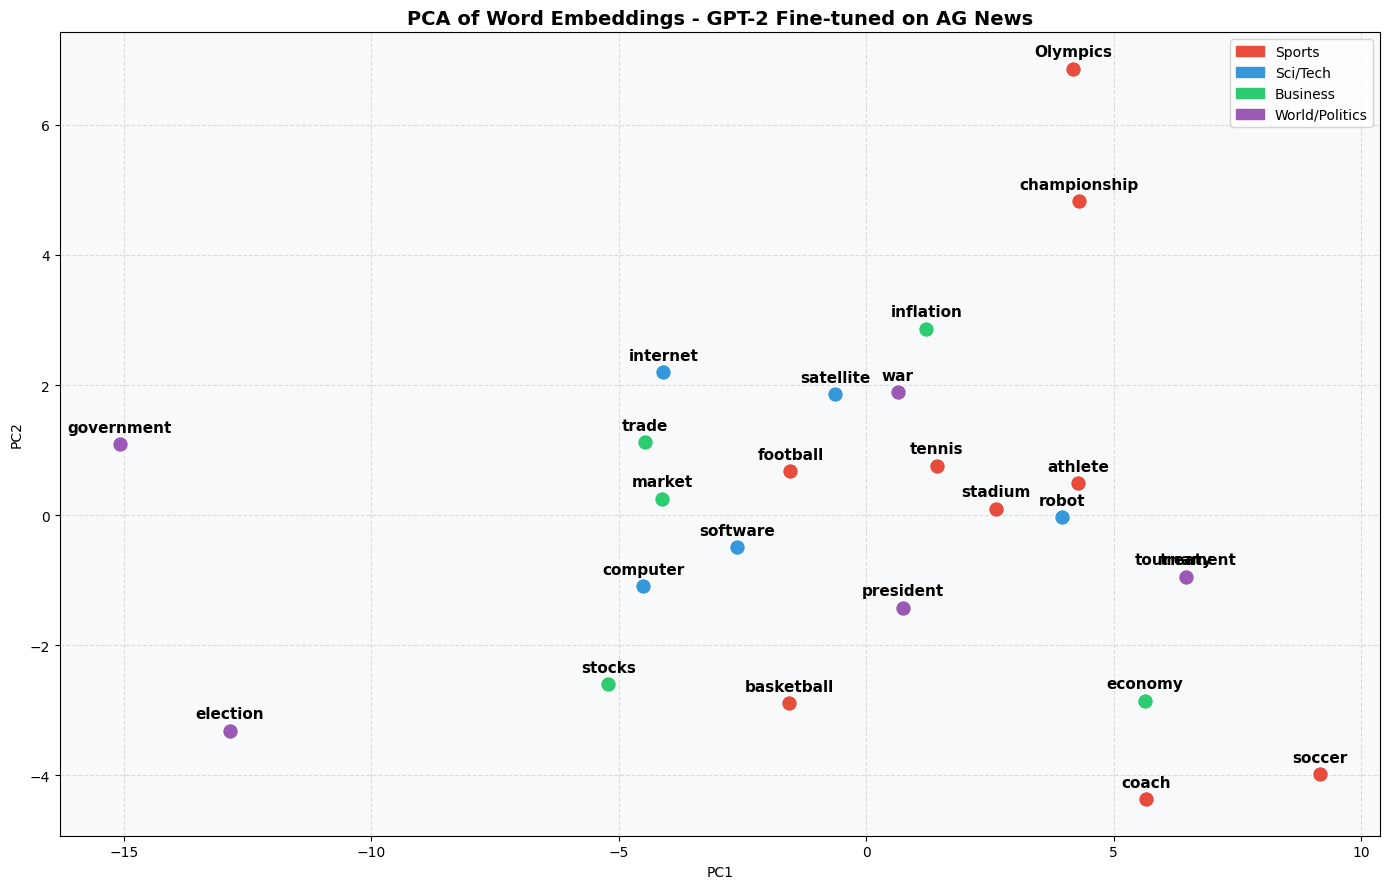

PCA saved as pca_word_embeddings.png


In [10]:
words = [
    'football','basketball','tennis','athlete','tournament',
    'championship','coach','stadium','Olympics','soccer',
    'computer','internet','satellite','robot','software',
    'stocks','economy','market','inflation','trade',
    'election','government','president','war','treaty',
]

embed_model = GPT2Model.from_pretrained('./gpt2-news-finetuned')
embed_model.eval()

embeddings = []
with torch.no_grad():
    for word in words:
        enc = tokenizer(word, return_tensors='pt')
        out = embed_model(**enc)
        embeddings.append(out.last_hidden_state[:, 0, :].squeeze().numpy())

reduced = PCA(n_components=2).fit_transform(np.array(embeddings))
colors  = ['#e74c3c']*10 + ['#3498db']*5 + ['#2ecc71']*5 + ['#9b59b6']*5

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#f8f9fa')

for i, (x, y) in enumerate(reduced):
    ax.scatter(x, y, color=colors[i], s=130, edgecolors='white', zorder=3)
    ax.annotate(words[i], (x, y), fontsize=11, fontweight='bold',
                ha='center', xytext=(0, 9), textcoords='offset points')

legend = [
    Patch(color='#e74c3c', label='Sports'),
    Patch(color='#3498db', label='Sci/Tech'),
    Patch(color='#2ecc71', label='Business'),
    Patch(color='#9b59b6', label='World/Politics'),
]
ax.legend(handles=legend, fontsize=10)
ax.set_title('PCA of Word Embeddings - GPT-2 Fine-tuned on AG News', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('pca_word_embeddings.png', dpi=150)
plt.show()
print('PCA saved as pca_word_embeddings.png')